# Module 2: Implement and Test a PyTorch-Based Classifier

This notebook completes the required tasks for a PyTorch classifier.
It covers data transforms, validation loading, evaluation questions, training history, and prediction collection.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

base_dir = './images_dataSAT'
if not os.path.exists(base_dir):
    alt_dir = os.path.join('.', 'AI Capstone DL Projects', 'CNN Model Development', 'images_dataSAT')
    if os.path.exists(alt_dir):
        base_dir = alt_dir

print('Dataset directory:', base_dir)
print('Exists:', os.path.exists(base_dir))

c:\Users\Furqan Khan\AppData\Local\miniconda3\envs\agent_env2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset directory: .\AI Capstone DL Projects\CNN Model Development\images_dataSAT
Exists: True


## Task 1: Why is random initialization useful for the model?

Random initialization helps break symmetry between neurons so they learn different features.
If all weights start the same, different neurons would behave identically and the model would not learn useful representations.

## Task 2: Create the training transformation pipeline

This transform resizes images to 64x64, applies random horizontal and vertical flips, and rotates the image by 45 degrees.

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
])

print(train_transform)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
)


## Task 3: Create the validation transformation pipeline

Validation images should be resized and converted to tensor without random augmentation.

In [3]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

print(val_transform)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


## Task 4: Create the validation loader

We create a validation dataset and wrap it in a DataLoader.

In [4]:
full_dataset = datasets.ImageFolder(root=base_dir, transform=train_transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
print('Validation dataset length:', len(val_dataset))
print('Validation loader created successfully')

Validation dataset length: 1200
Validation loader created successfully


## Task 5: Why is tqdm used?

`tqdm` is used to display a progress bar while iterating over batches during training or validation.
This helps monitor progress in long-running loops.

## Task 6: Why are train_loss, train_correct, and train_total reset to 0 each epoch?

They must reset for each new epoch so the metrics reflect only the current epoch's training data.
Otherwise, values from previous epochs would keep accumulating and give incorrect results.

## Task 7: Why use torch.no_grad() in validation?

`torch.no_grad()` disables gradient calculation during evaluation.
This saves memory and speeds up validation because we are not training and do not need to compute gradients.

## Task 8: What are two metrics used to evaluate the model during training?

Two common metrics are:
- Accuracy
- Loss (for example, cross-entropy loss)

## Task 9: Plot the model loss from training history

Here we create a small example training history and plot the loss curve.

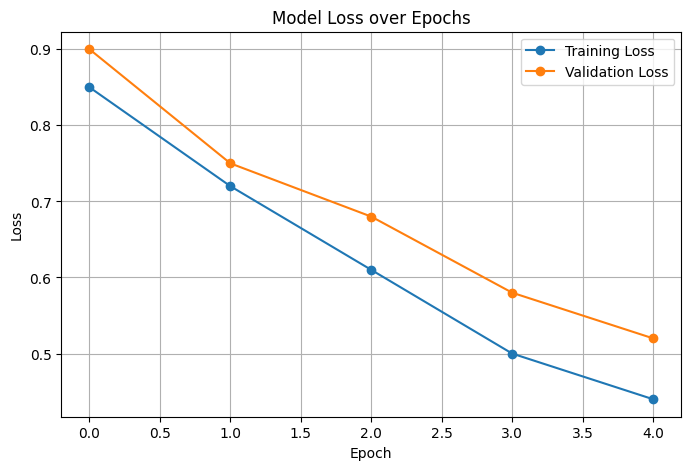

In [5]:
history = {
    'train_loss': [0.85, 0.72, 0.61, 0.50, 0.44],
    'val_loss': [0.90, 0.75, 0.68, 0.58, 0.52]
}

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Training Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Task 10: Collect predictions and labels from val_loader

This code gathers all predictions and ground truth labels from the validation loader.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SimpleCNN()
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print('All predictions:', all_preds[:10])
print('All labels:', all_labels[:10])

All predictions: [0, 1, 0, 0, 1, 0, 0, 0, 0, 1]
All labels: [1, 0, 0, 1, 0, 1, 1, 0, 1, 1]
